# pop gen vs quant gen rescue

In [1]:
from sympy import *
import matplotlib.pyplot as plt
import numpy as np

## pop gen

allele frequency dynamics, with $q$ the frequency of the wildtype allele. wildtype has fitness $-r$, mutant has fitness $s-r$.

In [2]:
s,t,q0 = var('s, t, q0') #define variables
q = Function('q')(t) #and functions

f = dsolve(
    Eq(Derivative(q, t), -q * (1-q) * s), #the differential equation we want to solve
    q, #the variable/function we want to solve for
    ivar = t, #the independent variable we want the function to be of
    ics = {q.subs(t,0): q0} #the initial conditions
)

qt = f.simplify()
qt

Eq(q(t), q0/(q0 - (q0 - 1)*exp(s*t)))

mean fitness dynamics

In [3]:
r = var('r')
wbar = -r*q + (-r+s)*(1-q) #mean fitness
wbart = wbar.subs(q,qt.rhs).simplify() #sub in q(t) solution
wbart

(-q0*r + (q0 - 1)*(r - s)*exp(s*t))/(q0 - (q0 - 1)*exp(s*t))

population dynamics

In [4]:
n0 = var('n0') #define variables
n = Function('n')(t) #and functions

f = dsolve(
    Eq(Derivative(n, t), wbart * n), #the differential equation we want to solve
    n, #the variable/function we want to solve for
    ivar = t, #the independent variable we want the function to be of
    ics = {n.subs(t,0): n0} #the initial conditions
)

nt = f.simplify()
nt

Eq(n(t), n0*(q0 + (1 - q0)*exp(s*t))*exp(-r*t))

## quant gen

fitness as a function of displacement from optimum, $d_i$

In [5]:
rmax,di = symbols('r_max,di')
w = symbols('w')
rdi = rmax - di**2/(2*w**2)

assume a normal distribution of displacements with mean $d$ and variance $v_z=v_g+v_e$

In [6]:
d=symbols('d')
vz = symbols('v_z', positive=True)
def normal(x, mean, sigma):
    z = (x - mean) / sigma
    return (1 / (sigma * sqrt(2 * pi))) * exp(-(z * z) / 2)
p = normal(di,d,sqrt(vz))

mean fitness

In [7]:
rmean = integrate(p*rdi,(di,-oo,oo)).simplify().expand()
rmean

-d**2/(2*w**2) + r_max - v_z/(2*w**2)

mean phenotype dynamics

In [8]:
vg,d0 = var('v_g,d0') #define variables
dt = Function('d')(t) #and functions

f = dsolve(
    Eq(Derivative(dt, t), vg * diff(rmean,d).subs(d,dt)), #the differential equation we want to solve
    dt, #the variable/function we want to solve for
    ivar = t, #the independent variable we want the function to be of
    ics = {dt.subs(t,0): d0} #the initial conditions
)

dtsol = f.simplify()
dtsol

Eq(d(t), d0*exp(-t*v_g/w**2))

mean fitness dynamics

In [9]:
rmeant=rmean.subs(d,dtsol.rhs)
rmeant

-d0**2*exp(-2*t*v_g/w**2)/(2*w**2) + r_max - v_z/(2*w**2)

population dynamics

In [10]:
n0 = var('n0') #define variables
n = Function('n')(t) #and functions

f = dsolve(
    Eq(Derivative(n, t), rmeant * n), #the differential equation we want to solve
    n, #the variable/function we want to solve for
    ivar = t, #the independent variable we want the function to be of
    # ics = {n.subs(t,0): n0} #the initial conditions
)

# ntqg = f.simplify()

c1sol = solve(f.rhs.args[0][0].subs(t,0) - n0, 'C1')[0]
ntqg = f.rhs.args[0][0].subs('C1',c1sol).simplify()

ntqg

n0*exp(-d0**2/(4*v_g) + d0**2*exp(-2*t*v_g/w**2)/(4*v_g) + r_max*t - t*v_z/(2*w**2))

# comparison

now lets make this comparable with pop gen. first, make final mean fitness the same

$-r+s = rmax - v_z/(2w^2)$

In [11]:
sub0 = solve(-r + s -rmax + vz/(2*w**2), rmax)[0]
rmeantsub = rmeant.subs(rmax,sub0)
rmeantsub

-d0**2*exp(-2*t*v_g/w**2)/(2*w**2) - r + s

now make initial mean fitness the same: $-r+(1-q_0)s = rmax - v_z/(2w^2) - d0^2/(2w^2) = -r + s - d0^2/(2w^2)$

In [12]:
sub1 = solve(-r + (1-q0)*s + r - s + d0**2/(2*w**2), d0**2)[0]
rmeantsubsub = rmeantsub.subs(d0**2,sub1).simplify().expand()
rmeantsubsub

-q0*s*exp(-2*t*v_g/w**2) - r + s

we still need to deal with the $v_g/w^2$, which is the rate of evolution. 

one way would be to set the time to reach replacement equal.

in the pop gen model this is

In [13]:
t0pg = solve(wbart,t)[0]
t0pg

log(q0*r/((q0 - 1)*(r - s)))/s

in the quant gen model this is

In [14]:
solve(rmeant, t)[1]

w**2*log(d0*sqrt(1/(2*r_max*w**2 - v_z)))/v_g

In [15]:
t0qg = solve(rmeant, t)[1].subs(rmax,sub0).subs(d0,sqrt(sub1)).simplify()
t0qg

w**2*log(sqrt(1/(w**2*(-r + s)))*sqrt(q0*s*w**2))/v_g

note the $w^2$ in the square root should cancel, giving

In [16]:
t0qg = w**2 * t0qg.subs(w,1)
t0qg

w**2*log(sqrt(q0*s)*sqrt(1/(-r + s)))/v_g

so vg can be replaced with

In [17]:
sub2=solve(t0pg-t0qg,vg)[0].simplify()
sub2

s*w**2*log(sqrt(-1/(r - s))*sqrt(q0*s))/log(q0*r/(q0*r - q0*s - r + s))

giving

In [18]:
rmeantsubsubsub = rmeantsubsub.subs(vg,sub2)
rmeantsubsubsub

-q0*s*exp(-2*s*t*log(sqrt(-1/(r - s))*sqrt(q0*s))/log(q0*r/(q0*r - q0*s - r + s))) - r + s

and the popn dynamics are

In [19]:
ntqgsub = ntqg.subs(rmax,sub0).subs(d0**2,sub1).subs(vg,sub2).simplify()
ntqgsub

n0*exp(-q0*log(q0*r/(q0*r - q0*s - r + s))/(2*log(sqrt(-1/(r - s))*sqrt(q0*s))) + q0*exp(-2*s*t*log(sqrt(-1/(r - s))*sqrt(q0*s))/log(q0*r/(q0*r - q0*s - r + s)))*log(q0*r/(q0*r - q0*s - r + s))/(2*log(sqrt(-1/(r - s))*sqrt(q0*s))) - r*t + s*t)

### plot

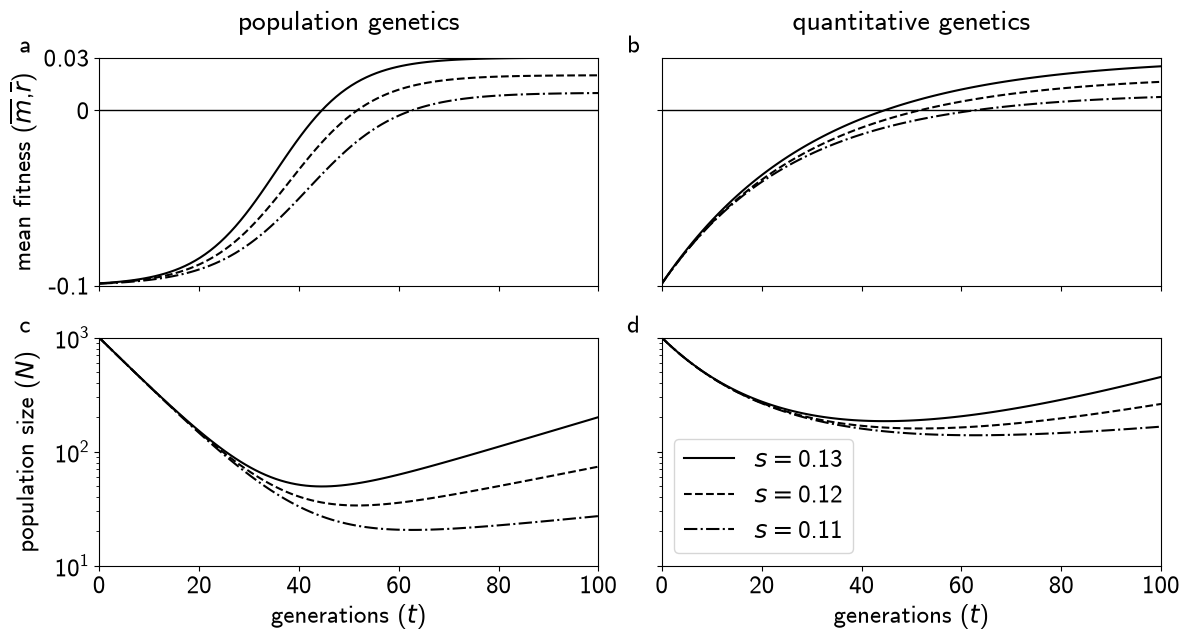

In [24]:
params = [(q0,0.99),(r,0.1),(n0,1000)]
ss = [0.13,0.12,0.11]
xs = np.linspace(0,100,100)
# plt.rcParams['font.family'] = 'Courier New'
# plt.rcParams['font.family'] = 'Helvetica'
# plt.rcParams['font.family'] = 'Computer Modern Serif'
plt.rcParams['font.weight'] = 'regular'

plt.rcParams['font.family'] = 'sans-serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs

# def forceAspect(ax,aspect=1/2,log=False):
#     xleft, xright = ax.get_xlim()
#     ybottom, ytop = ax.get_ylim()
#     if not log:
#         ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*aspect)
#     else:
#         ax.set_aspect(abs((xright-xleft)/(np.log10(ybottom)-np.log10(ytop)))*aspect)

fig, axs = plt.subplots(2,2,figsize=(12,6.5))
labelsize = 18
titlesize = 20
styles = ['k-','k--','k-.']
# cfont = {'fontname':'Courier New'}

ax = axs[0,0]
for i,si in enumerate(ss):
    ys = [wbart.subs(t,i).subs(params).subs(s,si) for i in xs]
    ax.plot(xs, ys, styles[i], label='$s =$%s'%si)
ax.plot(xs, [0 for _ in xs], 'k-', linewidth=1)
# ax.set_xlabel('time')
ax.set_ylabel(r'mean fitness ($\overline{m}$,$\overline{r}$)', fontsize=labelsize)
# ax.set_yticks([-r.subs(params),0],[r'$-r$',0])
ax.set_yticks([-r.subs(params),0,-r.subs(params) + max(ss)],[round(-r.subs(params),1),0,round(-r.subs(params)+max(ss),2)])
ax.set_title('population genetics', fontsize=titlesize, pad=20)
ax.set_ylim(float(-r.subs(params)),float(-r.subs(params)+max(ss)))
ax.set_xlim(min(xs),max(xs))
ax.xaxis.set_ticklabels([])
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.text(-16,-r.subs(params)+max(ss),'a',fontsize=labelsize, va='bottom')
   
ax = axs[1,0]
for i,si in enumerate(ss):
    ys = [nt.rhs.subs(t,i).subs(params).subs(s,si) for i in xs]
    ax.plot(xs, ys, styles[i], label='$s =$%s'%si)
ax.set_xlabel('generations ($t$)', fontsize=labelsize)
ax.set_ylabel('population size ($N$)', fontsize=labelsize, labelpad=10)
ax.set_yscale('log')
ax.set_ylim(10,float(n0.subs(params)))
ax.set_xlim(min(xs),max(xs))
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.text(-16,n0.subs(params),'c',fontsize=labelsize, va='bottom')

ax = axs[0,1]
for i,si in enumerate(ss):
    ys = [rmeantsubsubsub.subs(t,i).subs(params).subs(s,si) for i in xs]
    ax.plot(xs, ys, styles[i], label='$s =$%s'%si)
ax.plot(xs, [0 for _ in xs], 'k-', linewidth=1)
# ax.set_xlabel('time')
# ax.set_ylabel('mean fitness')
ax.set_yticks([-r.subs(params),0],['',''])
ax.set_title('quantitative genetics', fontsize=titlesize, pad=20)
ax.set_ylim(float(-r.subs(params)),float(-r.subs(params)+max(ss)))
ax.set_xlim(min(xs),max(xs))
ax.xaxis.set_ticklabels([])
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.text(-7,-r.subs(params)+max(ss),'b',fontsize=labelsize, va='bottom')
    
ax = axs[1,1]
for i,si in enumerate(ss):
    ys = [ntqgsub.subs(t,i).subs(params).subs(s,si) for i in xs]
    ax.plot(xs, ys, styles[i], label='$s =$%s'%si)
ax.set_xlabel('generations ($t$)', fontsize=labelsize)
# ax.set_ylabel('population size')
ax.set_yscale('log')
ax.set_ylim(10,float(n0.subs(params)))
ax.set_xlim(min(xs),max(xs))
ax.yaxis.set_ticklabels([])
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.text(-7,n0.subs(params),'d',fontsize=labelsize, va='bottom')

# for ax in axs[0]:
#     forceAspect(ax)
# for ax in axs[1]:
#     forceAspect(ax, log=True)
    
plt.legend(fontsize=labelsize)
plt.tight_layout()
plt.savefig(
    'pg-vs-qg.pdf',
    # dpi=600,              # 300+ for print, 600 for very fine detail
    bbox_inches='tight',  # trim excess whitespace
    pad_inches=0.05,      # small padding after trimming
    transparent=False,    # True if you want no background (for overlays)
    facecolor='white',    # explicit bg color if not transparent
)
plt.show()

## alternatively...

we can alternatively try to get rid of $v_g/w^2$ by setting the initial genetic variance in fitness to be equal (as in Gomulkiewicz et al 2010). in the pop gen model this is

In [259]:
wvar = ((-r-wbar.subs(q,q0))**2*q0 + ((-r+s)-wbar.subs(q,q0))**2*(1-q0)).simplify() 
wvar

q0*s**2*(1 - q0)

in the pop gen model it is

In [263]:
rvar = integrate(p*(rd-rmean)**2,(di,-oo,oo)).subs(vz,vg).subs(d,d0).simplify()
rvar

v_g*(2*d0**2 + v_g)/(2*w**4)

so $w^2$ is

In [267]:
sub2alt = solve(rvar.subs(d0**2,sub1) - wvar, w**2)[0]
sub2alt

v_g*(-2*q0 - sqrt(2)*sqrt(q0*(q0 + 1)))/(2*q0*s*(q0 - 1))

giving mean fitness

In [269]:
rmeantsub2 = rmeant.subs(rmax,sub0).subs(d0**2,sub1).subs(w**2,sub2alt).simplify()
rmeantsub2

-q0*s*exp(4*q0*s*t*(q0 - 1)/(2*q0 + sqrt(2)*sqrt(q0*(q0 + 1)))) - r + s

and popn dynamics

In [270]:
ntqgsub2 = ntqg.subs(rmax,sub0).subs(d0**2,sub1).subs(w**2,sub2alt).simplify()
ntqgsub2

n0*exp((-2*q0 + 4*t*(q0 - 1)*(-r + s)*exp(-4*q0*s*t*(q0 - 1)/(2*q0 + sqrt(2)*sqrt(q0*(q0 + 1)))) - sqrt(2)*sqrt(q0*(q0 + 1)) + (2*q0 + sqrt(2)*sqrt(q0*(q0 + 1)))*exp(-4*q0*s*t*(q0 - 1)/(2*q0 + sqrt(2)*sqrt(q0*(q0 + 1)))))*exp(4*q0*s*t*(q0 - 1)/(2*q0 + sqrt(2)*sqrt(q0*(q0 + 1))))/(4*(q0 - 1)))

### plot

In [271]:
params = [(q0,0.99),(r,0.1),(n0,1000)]
ss = [0.11,0.12,0.13]
xs = np.linspace(0,100,100)

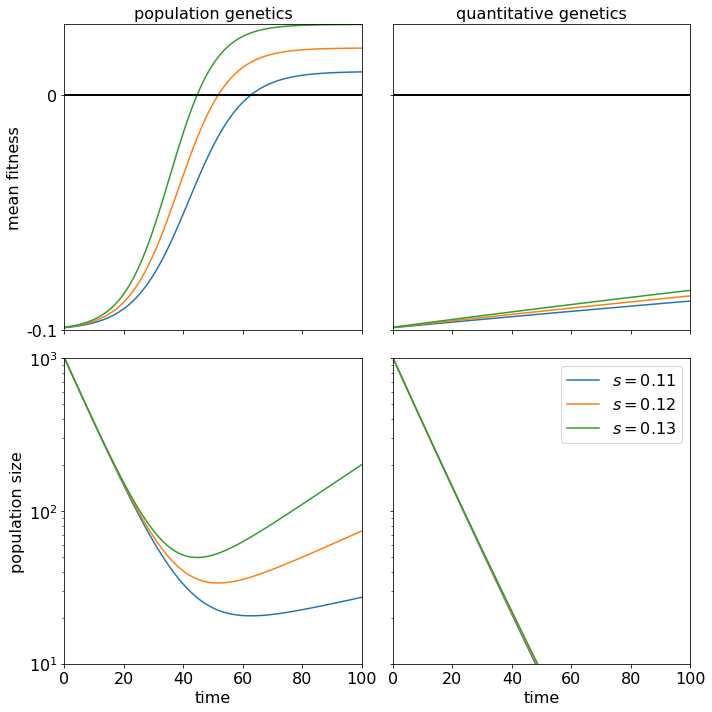

In [274]:
fig, axs = plt.subplots(2,2,figsize=(10,10))
labelsize = 16

for si in ss:

    ax = axs[0,0]
    ys = [wbart.subs(t,i).subs(params).subs(s,si) for i in xs]
    ax.plot(xs,ys, label='s=%s'%si)
    ax.plot(xs, [0 for _ in xs], c='k')
    # ax.set_xlabel('time')
    ax.set_ylabel('mean fitness', fontsize=labelsize)
    # ax.set_yticks([-r.subs(params),0],[r'$-r$',0])
    ax.set_yticks([-r.subs(params),0],[round(-r.subs(params),1),0])
    ax.set_title('population genetics', fontsize=labelsize)
    ax.set_ylim(float(-r.subs(params)),float(-r.subs(params)+max(ss)))
    ax.set_xlim(min(xs),max(xs))
    ax.xaxis.set_ticklabels([])
    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    
    ax = axs[1,0]
    ys = [nt.rhs.subs(t,i).subs(params).subs(s,si) for i in xs]
    ax.plot(xs,ys, label='s=%s'%si)
    ax.set_xlabel('time', fontsize=labelsize)
    ax.set_ylabel('population size', fontsize=labelsize)
    ax.set_yscale('log')
    ax.set_ylim(10,float(n0.subs(params)))
    ax.set_xlim(min(xs),max(xs))
    ax.tick_params(axis='both', which='major', labelsize=labelsize)

    ax = axs[0,1]
    ys = [rmeantsub2.subs(t,i).subs(params).subs(s,si) for i in xs]
    ax.plot(xs,ys, label='s=%s'%si)
    ax.plot(xs, [0 for _ in xs], c='k')
    # ax.set_xlabel('time')
    # ax.set_ylabel('mean fitness')
    ax.set_yticks([-r.subs(params),0],['',''])
    ax.set_title('quantitative genetics', fontsize=labelsize)
    ax.set_ylim(float(-r.subs(params)),float(-r.subs(params)+max(ss)))
    ax.set_xlim(min(xs),max(xs))
    ax.xaxis.set_ticklabels([])
    ax.tick_params(axis='both', which='major', labelsize=labelsize)
    
    ax = axs[1,1]
    ys = [ntqgsub2.subs(t,i).subs(params).subs(s,si) for i in xs]
    ax.plot(xs,ys, label=r'$s=$%s'%si)
    ax.set_xlabel('time', fontsize=labelsize)
    # ax.set_ylabel('population size')
    ax.set_yscale('log')
    ax.set_ylim(10,float(n0.subs(params)))
    ax.set_xlim(min(xs),max(xs))
    ax.yaxis.set_ticklabels([])
    ax.tick_params(axis='both', which='major', labelsize=labelsize)

plt.legend(fontsize=labelsize)
plt.tight_layout()
plt.savefig('pg-vs-gq_alt.png')
plt.show()